# Rep. 4. Checkpoint 3. Estrategias II

## Actividad. Estrategias neutrales de trading con datos reales
Esta actividad es necesaria para el reporte integrador 4.

Esta actividad complementa el contenido de la clase "Estrategias neutrales de trading con opciones".

Usando el código visto en clase y datos reales de SPY con vencimiento al 17 de abril de 2026, replicarás los payoff diagrams de las cuatro estrategias neutrales (butterfly, iron condor, covered call y protective put) y analizarás bajo qué condiciones de mercado y de volatilidad implícita tiene sentido cada una.

### Contexto
Las estrategias neutrales son la otra cara de la moneda del trading con opciones: en lugar de apostar a un movimiento, apuestas a la quietud. Vendes volatilidad, cobras prima y dejas que el tiempo trabaje a tu favor. Pero esa prima no es gratis: es la compensación por asumir el riesgo de que el mercado se mueva más de lo que esperas. Entender cuándo vender volatilidad (IV alta, mercado lateral, theta positiva) y cuándo no, es una de las decisiones más importantes que toma un trader de opciones.

### Instrucciones
Toma el código desarrollado en clase para las cuatro estrategias neutrales (butterfly, iron condor, covered call y protective put) y ejecútalo en tu notebook usando los precios mid reales de SPY con vencimiento 2026-04-17, obtenidos dinámicamente con yfinance (siguiendo el mismo patrón visto en clase). No necesitas escribir código nuevo: la actividad consiste en correr el código de clase con datos actualizados y presentar:

- El payoff diagram del butterfly spread
- El payoff diagram del iron condor
- El payoff diagram del covered call
- El payoff diagram del protective put
- Una tabla resumen con prima neta (pagada o cobrada), ganancia máxima, pérdida máxima y break-even(s) de cada estrategia (los valores ya se imprimen en el código de clase, basta con consolidarlos en una tabla)

### Preguntas
Responde dentro del notebook como celdas de texto (Markdown). Las respuestas deben estar fundamentadas en tus propias gráficas con los datos reales del día que corras el código.

- Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?
- Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.
- Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.
- El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.
- Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".
- ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.
- Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    if S0 is not None:
        plt.axvline(S0, color='blue', linewidth=1.5, linestyle='-.', label=f'S0 Actual ({S0:.2f})')
        
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
            
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento S_T')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
spy = yf.Ticker('SPY')
S0 = spy.history(period='1d')['Close'].iloc[-1]
fecha_vencimiento = '2026-04-17'

opciones = spy.option_chain(fecha_vencimiento)
calls = opciones.calls
puts = opciones.puts

def get_mid_price(df, target_strike):
    idx = (df['strike'] - target_strike).abs().idxmin()
    row = df.loc[idx]
    return (row['bid'] + row['ask']) / 2, row['strike']

# Parámetros generales
S_range = np.linspace(S0 * 0.8, S0 * 1.2, 500)
ancho = 10 

# --- Cálculos dinámicos para Butterfly ---
K2_bf_target = round(S0)
C1_bf, K1_bf = get_mid_price(calls, K2_bf_target - ancho)
C2_bf, K2_bf = get_mid_price(calls, K2_bf_target)
C3_bf, K3_bf = get_mid_price(calls, K2_bf_target + ancho)

# --- Cálculos dinámicos para Iron Condor ---
K_ps_target = round(S0) - ancho
P_l, K_pl = get_mid_price(puts, K_ps_target - ancho)
P_s, K_ps = get_mid_price(puts, K_ps_target)
C_s, K_cs = get_mid_price(calls, round(S0) + ancho)
C_l, K_cl = get_mid_price(calls, round(S0) + ancho + ancho)

# --- Cálculos dinámicos para Covered Call ---
C_cc, K_cc = get_mid_price(calls, round(S0) + ancho)

# --- Cálculos dinámicos para Protective Put ---
P_pp, K_pp = get_mid_price(puts, round(S0) - ancho)

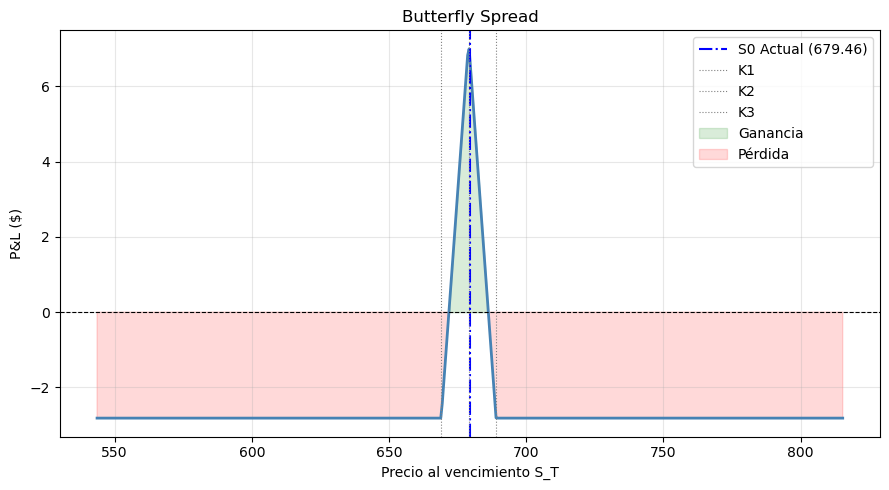

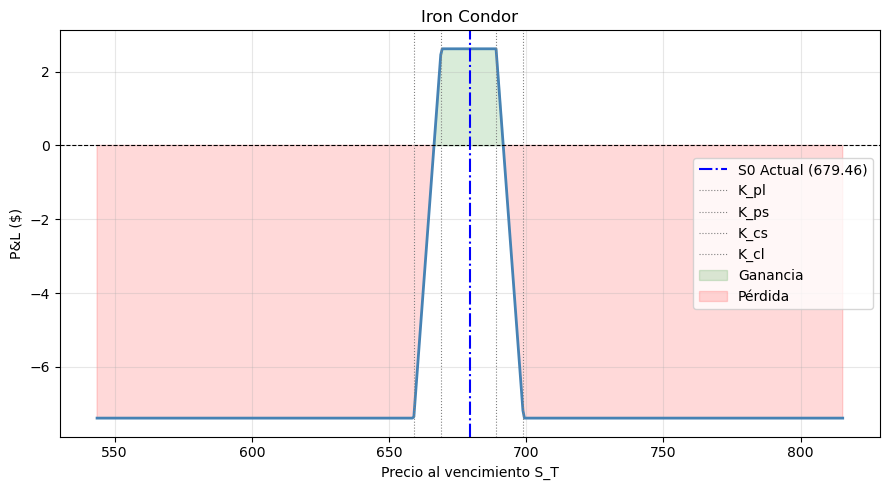

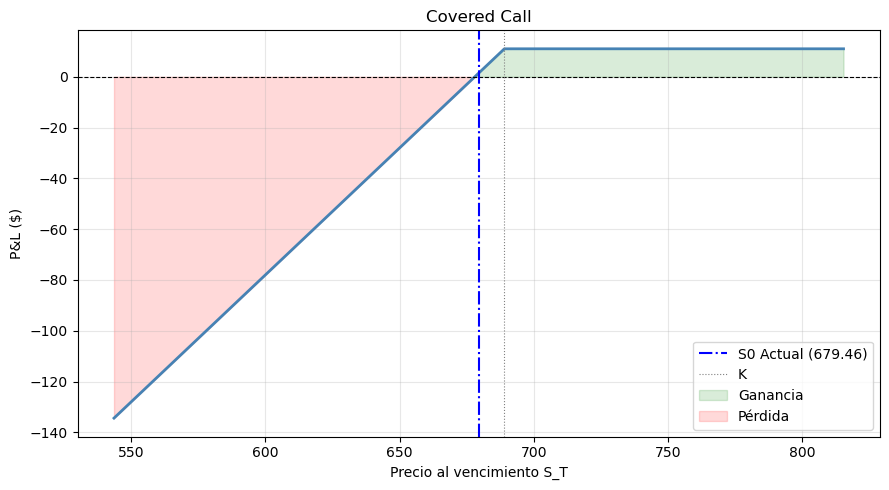

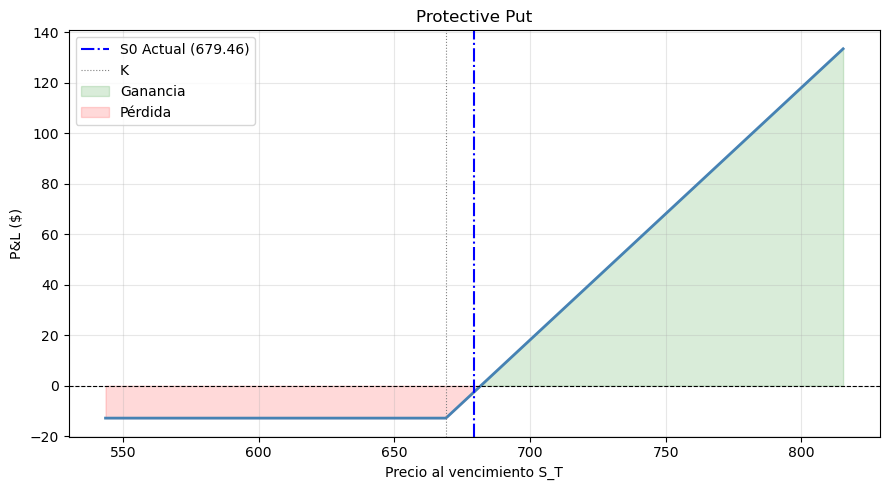

In [12]:
legs_butterfly = [
    {'tipo': 'call', 'K': K1_bf, 'prima': C1_bf, 'posicion': +1},
    {'tipo': 'call', 'K': K2_bf, 'prima': C2_bf, 'posicion': -2},
    {'tipo': 'call', 'K': K3_bf, 'prima': C3_bf, 'posicion': +1},
]
pnl_butterfly = payoff_estrategia(S_range, legs_butterfly)
graficar_estrategia(S_range, pnl_butterfly, 'Butterfly Spread', S0=S0, K_lines=[(K1_bf,'K1'),(K2_bf,'K2'),(K3_bf,'K3')])


legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1}
]
pnl_condor = payoff_estrategia(S_range, legs_condor)
graficar_estrategia(S_range, pnl_condor, 'Iron Condor', S0=S0, K_lines=[(K_pl,'K_pl'),(K_ps,'K_ps'),(K_cs,'K_cs'),(K_cl,'K_cl')])

legs_covered_call = [
    {'tipo': 'call', 'K': K_cc, 'prima': C_cc, 'posicion': -1}
]
pnl_covered_call = payoff_estrategia(S_range, legs_covered_call) + (S_range - S0)
graficar_estrategia(S_range, pnl_covered_call, 'Covered Call', S0=S0, K_lines=[(K_cc,'K')])


legs_protective_put = [
    {'tipo': 'put', 'K': K_pp, 'prima': P_pp, 'posicion': +1}
]
pnl_protective_put = payoff_estrategia(S_range, legs_protective_put) + (S_range - S0)
graficar_estrategia(S_range, pnl_protective_put, 'Protective Put', S0=S0, K_lines=[(K_pp,'K')])

In [13]:
prima_neta_bf = C1_bf - (2 * C2_bf) + C3_bf
max_ganancia_bf = (K2_bf - K1_bf) - prima_neta_bf
max_perdida_bf = prima_neta_bf


prima_neta_ic = P_s - P_l + C_s - C_l
max_ganancia_ic = prima_neta_ic
max_perdida_ic = ancho - prima_neta_ic

max_ganancia_cc = (K_cc - S0) + C_cc
max_perdida_cc = S0 - C_cc

max_perdida_pp = (S0 + P_pp) - K_pp

datos_resumen = {
    'Estrategia': ['Butterfly', 'Iron Condor', 'Covered Call', 'Protective Put'],
    'Vista del mercado': ['Se queda en K2', 'Se queda en rango', 'Lateral o sube poco', 'Protección downside'],
    'Ganancia máx.': [
        f"${max_ganancia_bf:.2f}", 
        f"${max_ganancia_ic:.2f}", 
        f"${max_ganancia_cc:.2f}", 
        "Ilimitada"
    ],
    'Pérdida máx.': [
        f"${max_perdida_bf:.2f}", 
        f"${max_perdida_ic:.2f}", 
        f"${max_perdida_cc:.2f}", 
        f"${max_perdida_pp:.2f}"
    ],
    'Vega': ['Negativa', 'Negativa', 'Negativa', 'Positiva']
}

df_resumen = pd.DataFrame(datos_resumen)

df_resumen

,Estrategia,Vista del mercado,Ganancia máx.,Pérdida máx.,Vega
0,Butterfly,Se queda en K2,$7.19,$2.81,Negativa
1,Iron Condor,Se queda en rango,$2.62,$7.38,Negativa
2,Covered Call,Lateral o sube poco,$11.02,$677.98,Negativa
3,Protective Put,Protección downside,Ilimitada,$12.83,Positiva


## Preguntas
Responde dentro del notebook como celdas de texto (Markdown). Las respuestas deben estar fundamentadas en tus propias gráficas con los datos reales del día que corras el código.

**1. Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?**
- El Butterfly como el Iron Condor se encuentran de inicio en su zona de máxima ganancia. Deberia de tener una vision neutral y esperar que el mercado no tenga movimientos muy agresivos.

**2. Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.**
- El iron condor sí es una estrategia con riesgo; el peor escenario puede ocurrir si el mercado tiene un movimiento fuerte, independientemente de la dirección. Su pérdida máxima es de $7.38; esto se calculó con el ancho del spread menos la prima cobrada.

**3. Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.**
- Un Iron Condor, la razón es el precio de las primas; con IV alto, el valor de las primas será altísimo, por lo que comprar un straddle será muy caro. Dependeré de que el mercado sí mantenga esa volatilidad alta para que evite pérdidas, mientras que si vendo un Iron Condor, yo me veo beneficiado por las primas altas y espero que el mercado no se mueva de manera tan brusca por tanto tiempo. Con IV alta, las opciones están caras, por lo que conviene ser vendedor de volatilidad (Vega negativa) esperando que la IV caiga. Además, al ser un crédito neto, el paso del tiempo (theta) juega a mi favor, especialmente hablando del SPY.

**4. El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.** 
- Permite cobrar extra en un mercado constante o lento, tambien la prima cobrada otorga un pequeño colchón de protección en caso de un movimiento brusco del mercado.

**5. Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".**
- La prima es el costo del seguro, la duración es la vigencia de la póliza y la diferencia entre S0 y el Strike es el deducible. Si no "chocas" (el mercado no cae), pierdes el pago del seguro (prima), pero sigues conservando tu auto (acciones) que incluso pudo haberse apreciado de valor de forma ilimitada. Además, puedes revender tu "seguro" antes de que expire si aún tiene valor temporal.

**6. ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.**
- El butterfly requiere una mayor precision respecto al precio del SPY, ya que el precio debe terminar exactamente en tu k2 para tener tu ganancia maxima. Mientras que el iron condor te da un rango mas amplio pero una ganancia menor.

**7. Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?**
- Si la IV cae 5 puntos y el precio no se mueve, el valor de tu posición aumenta, porque estas coberturas se ven beneficiadas por caidas en la volatilidad.